# Loading Libraries and Packages

In [25]:
import copy, math, os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torchvision.models as models
from torchvision.transforms.functional import affine
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict

# Setting the random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    print(f"MPS available. \nUsing MPS as runtime.")
    device = torch.device("mps")
    
elif torch.cuda.is_available():
    print(f"CUDA available. \nUsing CUDA as runtime.")
    device = torch.device("cuda")

else:
    print(f"No GPU available. \nUsing CPU runtime.")
    device = torch.device('cpu')

MPS available. 
Using MPS as runtime.


# 6.16 Transfer Learning & Freezing

## Dataset and Dataloaders

In [6]:
class AptosDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, is_test=False):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id_code']
        img_path = os.path.join(self.img_dir, img_id + ".png")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, img_id  # no label
        else:
            label = self.df.iloc[idx]['diagnosis']
            return image, label

## Stratified Sampling

In [21]:
root_dir = "../aptos2019-blindness-detection"
train_dir = os.path.join(root_dir,"train.csv")
df = pd.read_csv(train_dir)

# Step 1: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['diagnosis'],
    random_state=42
)

# Step 2: Split temp into 15% val and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # half of 30% → 15%
    stratify=temp_df['diagnosis'],
    random_state=42
)

train_data_path = os.path.join(root_dir,"train_split.csv")
val_data_path = os.path.join(root_dir,"val_split.csv")
test_data_path = os.path.join(root_dir,"test_split.csv")

# Save splits
train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Train data size:", len(train_df))
print("Validation data size:", len(val_df))
print("Validation data size:", len(test_df))

def check_distribution(df, name):
    print(f"\n{name} distribution:")
    print(df['diagnosis'].value_counts(normalize=True))

print()
print("#"*20, "STRATIFIED SAMPLING OUTPUT", "#"*20)
check_distribution(train_df, "Train")
check_distribution(val_df, "Validation")
check_distribution(test_df, "Test")

Train data size: 2563
Validation data size: 549
Validation data size: 550

#################### STRATIFIED SAMPLING OUTPUT ####################

Train distribution:
diagnosis
0    0.492782
2    0.272727
1    0.101053
4    0.080765
3    0.052673
Name: proportion, dtype: float64

Validation distribution:
diagnosis
0    0.493625
2    0.273224
1    0.100182
4    0.080146
3    0.052823
Name: proportion, dtype: float64

Test distribution:
diagnosis
0    0.492727
2    0.272727
1    0.101818
4    0.080000
3    0.052727
Name: proportion, dtype: float64


## Resnet-18 Model

In [26]:
class ResNet18Transfer(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Load pretrained model
        self.model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Freeze all layers
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace final FC layer
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [27]:
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return trainable, frozen

model = ResNet18Transfer()

trainable, frozen = count_parameters(model)
print(f"Trainable params: {trainable}")
print(f"Frozen params: {frozen}")

Trainable params: 2565
Frozen params: 11176512


In [52]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(
    model,
    train_loader,
    val_loader,
    device,
    model_save_path,
    epochs=50,
    lr=1e-3,
    patience=3,
    log_interval=25
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.model.fc.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):

        # ---- TRAIN ----
        model.train()
        train_loss = 0
        running_loss = 0

        correct_train = 0
        total_train = 0

        total_batches = len(train_loader)

        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            # Loss accumulation
            train_loss += loss.item() * images.size(0)
            running_loss += loss.item()

            # Accuracy
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            # Batch logging
            if batch_idx % log_interval == 0 or batch_idx == total_batches:
                avg_loss = running_loss / log_interval
                progress = (batch_idx / total_batches) * 100

                print(f"[Epoch {epoch+1} | Batch {batch_idx}/{total_batches} ({progress:.1f}%)] "
                      f"Batch Loss: {avg_loss:.4f}")

                running_loss = 0

        train_loss /= len(train_loader.dataset)
        train_acc = correct_train / total_train

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # ---- EPOCH SUMMARY ----
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}\n")

        # ---- EARLY STOPPING ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    return train_losses, val_losses, train_accs, val_accs

## Dataset and DataLoaders (With Necessary Transforms)

In [77]:
train_dir = os.path.join(root_dir,"train.csv")
img_dir = os.path.join(root_dir,"train_images")

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

train_dataset = AptosDataset( csv_file= train_data_path,img_dir= img_dir,transform=train_transforms)
val_dataset = AptosDataset(csv_file= val_data_path, img_dir= img_dir, transform=val_transforms)
test_dataset = AptosDataset(csv_file= test_data_path, img_dir= img_dir, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,        
    # num_workers=4,
    # pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    # num_workers=4,
    # pin_memory=True
)

test_loader = DataLoader( test_dataset, batch_size=64, shuffle=False)

## Driver Code

In [54]:
# Check one batch
images, labels = next(iter(train_loader))

print("Train batch images shape:", images.shape)   # [B, 3, 224, 224]
print("Train batch labels shape:", labels.shape)   # [B]

Train batch images shape: torch.Size([64, 3, 224, 224])
Train batch labels shape: torch.Size([64])


In [57]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = "../Models"
model_num = 2
model_save_path = os.path.join(save_dir, f"6_16_{model_num}.pth")

model = ResNet18Transfer(num_classes=5)

train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader,
    device, model_save_path = model_save_path,
    epochs=50, lr=1e-3, patience=3)

[Epoch 1 | Batch 25/41 (61.0%)] Batch Loss: 1.2423
[Epoch 1 | Batch 41/41 (100.0%)] Batch Loss: 0.6031

Epoch [1/50]
Train Loss: 1.1355 | Train Acc: 0.6122
Val Loss:   0.9170 | Val Acc:   0.6903

[Epoch 2 | Batch 25/41 (61.0%)] Batch Loss: 0.8839
[Epoch 2 | Batch 41/41 (100.0%)] Batch Loss: 0.4918

Epoch [2/50]
Train Loss: 0.8531 | Train Acc: 0.6898
Val Loss:   0.8320 | Val Acc:   0.7158

[Epoch 3 | Batch 25/41 (61.0%)] Batch Loss: 0.7539
[Epoch 3 | Batch 41/41 (100.0%)] Batch Loss: 0.4954

Epoch [3/50]
Train Loss: 0.7525 | Train Acc: 0.7269
Val Loss:   0.7818 | Val Acc:   0.7086

[Epoch 4 | Batch 25/41 (61.0%)] Batch Loss: 0.7139
[Epoch 4 | Batch 41/41 (100.0%)] Batch Loss: 0.4422

Epoch [4/50]
Train Loss: 0.7010 | Train Acc: 0.7515
Val Loss:   0.7628 | Val Acc:   0.7049

[Epoch 5 | Batch 25/41 (61.0%)] Batch Loss: 0.6814
[Epoch 5 | Batch 41/41 (100.0%)] Batch Loss: 0.4309

Epoch [5/50]
Train Loss: 0.6855 | Train Acc: 0.7472
Val Loss:   0.7521 | Val Acc:   0.7122

[Epoch 6 | Batch 25/

In [58]:
def load_model(model_class, model_path, device):
    model = model_class()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

In [59]:
model = load_model(ResNet18Transfer, model_save_path, device)

In [60]:
def evaluate_model(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print(f"Test Accuracy: {accuracy:.4f}")

    return accuracy, all_preds, all_labels

In [64]:
test_acc, preds, labels = evaluate_model(model, test_loader, device)

Test Accuracy: 0.7600


In [62]:
import matplotlib.pyplot as plt

def plot_loss_curves(
    val_losses,
    train_losses=None,
    save_path=None,
    title="Training and Validation Loss"
):
    epochs = range(1, len(val_losses) + 1)

    plt.figure(figsize=(8, 5))

    # Plot validation loss
    plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)

    # Optional: plot training loss
    if train_losses is not None:
        plt.plot(epochs, train_losses, linestyle='--', label="Train Loss", linewidth=2)

    # Labels and title
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.title(title, fontsize=14)

    # Ticks
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Grid (major + minor)
    plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    plt.minorticks_on()
    plt.grid(which='minor', linestyle='--', linewidth=0.3, alpha=0.5)

    # Legend
    plt.legend(fontsize=10)

    # Tight layout
    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

Plot saved to ../Report/6_12_loss.png


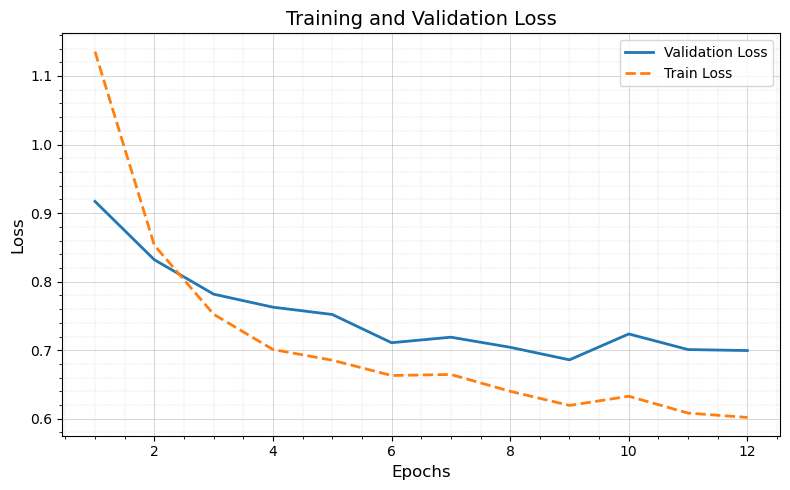

In [63]:
# plot_loss_curves(val_losses)
img_save_path = "../Report/6_12_loss.png"
plot_loss_curves(train_losses=train_losses, val_losses=val_losses,save_path = img_save_path)

# 6.17 Ordinal Imbalance & Focal Loss

In [78]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # tensor of shape [num_classes]
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits: [B, C]
        targets: [B]
        """

        log_probs = F.log_softmax(logits, dim=1)   # log(p)
        probs = torch.exp(log_probs)               # p

        # Select probabilities corresponding to true class
        targets = targets.view(-1, 1)
        log_pt = log_probs.gather(1, targets).squeeze(1)
        pt = probs.gather(1, targets).squeeze(1)

        # Focal loss term
        focal_term = (1 - pt) ** self.gamma

        # Alpha weighting (optional)
        if self.alpha is not None:
            alpha_t = self.alpha[targets.squeeze(1)]
            loss = -alpha_t * focal_term * log_pt
        else:
            loss = -focal_term * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [79]:
def compute_class_weights(df):
    counts = df['diagnosis'].value_counts().sort_index().values
    weights = 1.0 / counts
    weights = weights / weights.sum()  # normalize
    return torch.tensor(weights, dtype=torch.float32)

In [80]:
alpha = compute_class_weights(train_df).to(device)
criterion = FocalLoss(gamma=2.0, alpha=alpha)

In [72]:
def quadratic_weighted_kappa(y_true, y_pred, num_classes=5):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    O = np.zeros((num_classes, num_classes), dtype=np.float64)
    for t, p in zip(y_true, y_pred):
        O[t, p] += 1

    hist_true = np.bincount(y_true, minlength=num_classes)
    hist_pred = np.bincount(y_pred, minlength=num_classes)

    E = np.outer(hist_true, hist_pred) / len(y_true)

    W = np.zeros((num_classes, num_classes), dtype=np.float64)
    for i in range(num_classes):
        for j in range(num_classes):
            W[i, j] = ((i - j) ** 2) / ((num_classes - 1) ** 2)

    numerator = np.sum(W * O)
    denominator = np.sum(W * E)

    return 1 - (numerator / denominator)

In [70]:
def evaluate_qwk(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    qwk = quadratic_weighted_kappa(all_labels, all_preds)

    print(f"QWK Score: {qwk:.4f}")

    return qwk

In [73]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    model_save_path,
    train_df,
    epochs=50,
    lr=1e-3,
    patience=3,
    log_interval=25,
    gamma=2.0
):

    model = model.to(device)
    alpha = compute_class_weights(train_df).to(device)

    # ---- LOSS ----
    criterion = FocalLoss(gamma=gamma, alpha=alpha)

    optimizer = optim.Adam(model.model.fc.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_qwks, val_qwks = [], []

    for epoch in range(epochs):

        # ---- TRAIN ----
        model.train()
        train_loss = 0
        running_loss = 0

        correct_train = 0
        total_train = 0

        train_preds_all = []
        train_labels_all = []

        total_batches = len(train_loader)

        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            # Loss
            train_loss += loss.item() * images.size(0)
            running_loss += loss.item()

            # Accuracy
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            # Store for QWK
            train_preds_all.extend(preds.cpu().numpy())
            train_labels_all.extend(labels.cpu().numpy())

            # Batch logging
            if batch_idx % log_interval == 0 or batch_idx == total_batches:
                avg_loss = running_loss / log_interval
                progress = (batch_idx / total_batches) * 100

                print(f"[Epoch {epoch+1} | Batch {batch_idx}/{total_batches} ({progress:.1f}%)] "
                      f"Batch Loss: {avg_loss:.4f}")

                running_loss = 0

        train_loss /= len(train_loader.dataset)
        train_acc = correct_train / total_train
        train_qwk = quadratic_weighted_kappa(train_labels_all, train_preds_all)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_qwks.append(train_qwk)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        val_preds_all = []
        val_labels_all = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

                val_preds_all.extend(preds.cpu().numpy())
                val_labels_all.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val
        val_qwk = quadratic_weighted_kappa(val_labels_all, val_preds_all)

        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_qwks.append(val_qwk)

        # ---- EPOCH SUMMARY ----
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | QWK: {train_qwk:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | QWK: {val_qwk:.4f}\n")

        # ---- EARLY STOPPING ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    return train_losses, val_losses, train_accs, val_accs, train_qwks, val_qwks

In [74]:
save_dir = "../Models"
model_num = 1
model_save_path = os.path.join(save_dir, f"6_17_{model_num}.pth")

model = ResNet18Transfer(num_classes=5)

train_losses, val_losses, train_accs, val_accs, train_qwks, val_qwks = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    model_save_path=model_save_path,
    train_df=train_df,
    epochs=50,
    lr=1e-3,
    patience=3,
    log_interval=25,
    gamma=2.0
)

[Epoch 1 | Batch 25/41 (61.0%)] Batch Loss: 0.1001
[Epoch 1 | Batch 41/41 (100.0%)] Batch Loss: 0.0514

Epoch [1/50]
Train Loss: 0.0938 | Acc: 0.4651 | QWK: 0.4531
Val   Loss: 0.0785 | Acc: 0.6393 | QWK: 0.6858

[Epoch 2 | Batch 25/41 (61.0%)] Batch Loss: 0.0728
[Epoch 2 | Batch 41/41 (100.0%)] Batch Loss: 0.0433

Epoch [2/50]
Train Loss: 0.0715 | Acc: 0.6118 | QWK: 0.6920
Val   Loss: 0.0787 | Acc: 0.5902 | QWK: 0.6735

[Epoch 3 | Batch 25/41 (61.0%)] Batch Loss: 0.0674
[Epoch 3 | Batch 41/41 (100.0%)] Batch Loss: 0.0385

Epoch [3/50]
Train Loss: 0.0654 | Acc: 0.6465 | QWK: 0.7183
Val   Loss: 0.0648 | Acc: 0.6539 | QWK: 0.7405

[Epoch 4 | Batch 25/41 (61.0%)] Batch Loss: 0.0617
[Epoch 4 | Batch 41/41 (100.0%)] Batch Loss: 0.0386

Epoch [4/50]
Train Loss: 0.0612 | Acc: 0.6793 | QWK: 0.7429
Val   Loss: 0.0723 | Acc: 0.6393 | QWK: 0.7715

[Epoch 5 | Batch 25/41 (61.0%)] Batch Loss: 0.0631
[Epoch 5 | Batch 41/41 (100.0%)] Batch Loss: 0.0414

Epoch [5/50]
Train Loss: 0.0614 | Acc: 0.6609 | 

Plot saved to ../Report/6_17_loss_qwk.png


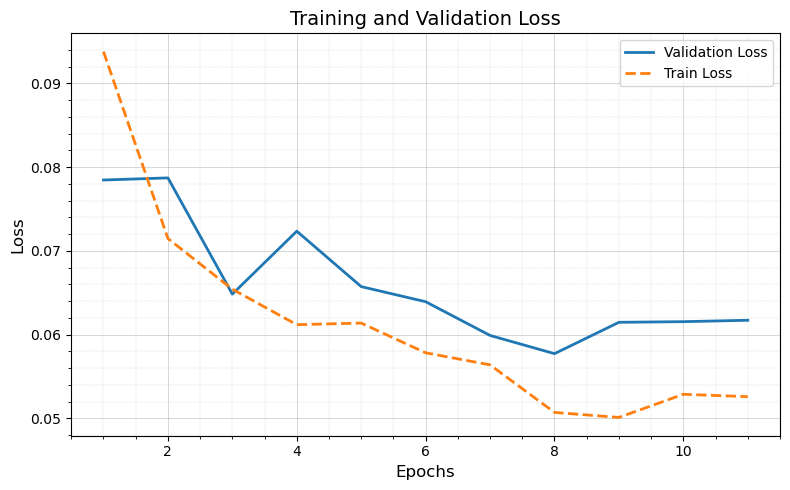

In [75]:
img_save_path = "../Report/6_17_loss_qwk.png"
plot_loss_curves(train_losses=train_losses, val_losses=val_losses,save_path = img_save_path)

In [76]:
model = load_model(ResNet18Transfer, model_save_path, device)
test_acc, preds, labels = evaluate_model(model, test_loader, device)

Test Accuracy: 0.7055
